In [18]:
import os
# Get the name of the current conda environment
env_name = os.getenv("CONDA_DEFAULT_ENV")
print(f"The current Conda environment is: {env_name}")

The current Conda environment is: tensorflow_env


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

In [25]:
def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))

In [41]:
# Define start and end dates as datetime objects
start_date = pd.to_datetime("2000-01-01")
end_date = pd.to_datetime("2100-12-31")

In [42]:
epochs=256
batch_size=16
os.chdir('F:\\geodata\\river_runoff_obs')

In [43]:
valid_rate = 0.3

In [52]:
X_train.shape

(164, 3)

In [44]:
input_file_name_list = ['1_hsg_imputMF','2_dsk_imputMF','3_xhl_imputMF','4_slglk_imputMF','5_kq_imputMF','6_wlwt_imputMF','7_tgzlk_imputMF']
input_file_name_list = [ '2_dsk_imputMF','3_xhl_imputMF','4_slglk_imputMF','5_kq_imputMF','6_wlwt_imputMF','7_tgzlk_imputMF']

In [59]:
predictions

array([[-0.55511004, -0.5149522 ],
       [-0.61576307, -0.5700493 ],
       [-0.34168145, -0.37719002],
       [-0.15076768, -0.18890616],
       [-0.35197768, -0.36641827],
       [-0.2969524 , -0.3012003 ],
       [-0.48746893, -0.4691669 ],
       [-0.5947635 , -0.5597631 ],
       [-0.5771825 , -0.5197848 ],
       [-0.56192666, -0.5206238 ],
       [-0.5337029 , -0.5215962 ],
       [-0.5328541 , -0.5147898 ],
       [-0.58784294, -0.55302715],
       [-0.52005136, -0.4838076 ],
       [-0.5474782 , -0.53289783],
       [-0.49500158, -0.5373851 ],
       [-0.53276783, -0.56006813],
       [-0.57187146, -0.5970514 ],
       [-0.42752233, -0.47850755],
       [-0.47561213, -0.5215063 ],
       [-0.64438945, -0.68583024],
       [-0.56490886, -0.6136309 ],
       [-0.44763145, -0.48157695],
       [-0.5099418 , -0.51071143],
       [-0.33844426, -0.29586574],
       [-0.27497613, -0.2108868 ],
       [-0.34043643, -0.27334577],
       [-0.2910392 , -0.23486122],
       [-0.30760166,

In [60]:
        runoff_observed = y_test_rescaled[:, 0]
        evaporation_observed = y_test_rescaled[:, 1]
        runoff_predicted = predictions_rescaled[:, 0]
        evaporation_predicted = predictions_rescaled[:, 1]

IndexError: index 1 is out of bounds for axis 1 with size 1

In [65]:
        pred_df


,predicted_runoff,predicted_ep
0,67.240189,75.745232
1,54.394451,64.076202
2,112.442299,104.921928
3,152.875992,144.798630
4,110.261658,107.203278
5,121.915482,121.015816
6,81.565918,85.442116
7,58.841961,66.254723
8,62.565456,74.721733
9,65.796494,74.544037


In [66]:
from datetime import datetime# 获取当前时间
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
# 创建文件名
txtbook_path = f'F:\\geodata\\river_runoff_obs\\note\\note_{current_time}.txt'
print(txtbook_path)

print(epochs,batch_size,valid_rate)
for input_file_name in input_file_name_list:
    print(epochs,batch_size,valid_rate)
    abbre = file_name.split('_')[1]
    for scenario in ['ssp126','ssp245','ssp370','ssp585']:
        print(scenario)
        
        # Dataset loading
        name = f'{input_file_name}_BCC-CSM2-MR_{scenario}_r1i1p1f1_mon'
        csv_path = f"{name}.csv"
        usecols = ['time', 'pre', 'tm', 'gr', 'dis','ep']
        df_full = pd.read_csv(csv_path, usecols=usecols)
        df_full = df_full[-1212:]
        df = df_full.dropna()
        df_future = df_full[df_full.dis.isnull()]
        file_name = f'{name}_{epochs}_{batch_size}'
        # Prepare features (X) and targets (y)
        X = df[['pre', 'tm', 'gr']].values  # Inputs: precipitation, temperature, mass balance
        y = df[['dis', 'ep']].values         # Outputs: runoff (dis) and evaporation (ep)
        
        import numpy as np
        from sklearn.preprocessing import StandardScaler
        from sklearn.model_selection import train_test_split
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten
        
        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=valid_rate, random_state=42)
        
        
        # Standardize the data
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        X_train = scaler_X.fit_transform(X_train)
        X_test = scaler_X.transform(X_test)
        y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
        y_test = scaler_y.transform(y_test.reshape(-1, 1))
        
        # Set time step
        time_step = 32
        
        # Function to create sequences with a time step
        def create_sequences(X, y, time_step):
            X_seq, y_seq = [], []
            for i in range(len(X) - time_step):
                X_seq.append(X[i:i+time_step])  # Sequence of length 'time_step'
                y_seq.append(y[i+time_step])   # Target corresponding to the end of the sequence
            return np.array(X_seq), np.array(y_seq)
        
        # Create sequences for training and testing
        X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_step)
        X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_step)
        
        # Reshape for LSTM input (samples, time_step, features)
        X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], time_step, X_train_seq.shape[2]))
        X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], time_step, X_test_seq.shape[2]))
        
        # Define the model
        model = Sequential([
            LSTM(128, activation='tanh', return_sequences=True, input_shape=(time_step, X_train_seq.shape[2])),
            Dropout(0.2),  # Dropout with 20%
            LSTM(64, activation='tanh'),
            Dropout(0.2),  # Dropout with 20%
            Dense(32, activation='relu'),
            Dense(2)  # Output layer with two units for runoff and evaporation
        ])
        
        # Compile the model
        model.compile(optimizer='adam', loss='mse')
        
        # Train the model
        history = model.fit(
            X_train_seq, y_train_seq,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=valid_rate
        )
        
                
        # Make predictions
        predictions = model.predict(X_test_seq)
        predictions_rescaled = scaler_y.inverse_transform(predictions)
        
        # Convert predictions to DataFrame for runoff and evaporation
        pred_df = pd.DataFrame(predictions_rescaled, columns=['predicted_runoff', 'predicted_ep'])
        print(pred_df.head())
        from sklearn.metrics import mean_squared_error
        # # Calculate predictions and rescale
        # predictions = model.predict(X_test_seq)
        # y_test_rescaled = scaler_y.inverse_transform(predictions)
        # 
        # runoff_observed = y_test_rescaled[:, 0]
        # evaporation_observed = y_test_rescaled[:, 1]
        # runoff_predicted = predictions_rescaled[:, 0]
        # evaporation_predicted = predictions_rescaled[:, 1]
        # 
        
        # Assuming future_df is loaded and has the same columns as df
        # Extract features from future_df
        X_full = df_full[['pre', 'tm', 'gr']].values  # Only the input features
        # Standardize features based on the training data scaler
        
                # Preprocess the future data (X_full)
        X_full_scaled = scaler_X.transform(X_full)
        
        # Create sequences for X_full with the same time_step
        X_full_seq, _ = create_sequences(X_full_scaled, np.zeros(X_full_scaled.shape[0]), time_step)
        
        # Reshape for LSTM input (samples, time_step, features)
        X_full_seq = X_full_seq.reshape((X_full_seq.shape[0], time_step, X_full_seq.shape[2]))
        
        # Use the trained model to predict future runoff and evaporation
        future_predictions = model.predict(X_full_seq)
        
        # Inverse transform the predictions to get the original scale (back to original units)
        full_predictions = scaler_y.inverse_transform(future_predictions)
        
        # If needed, convert the predictions back into a DataFrame or a suitable format for use
        predicted_runoff_evaporation = pd.DataFrame(future_predictions, columns=['runoff', 'evaporation'])
       
        # Convert predictions to DataFrame for readability
        # Ensure that the DataFrame has the required columns
        df_full[['Projected_Runoff', 'Projected_Evaporation']] = np.nan  # Initialize with NaN
        
        # Assign the predictions to the appropriate rows
        df_full.iloc[- len(full_predictions) :, df_full.columns.get_loc('Projected_Runoff'):] = full_predictions
        print(df_full[['Projected_Runoff', 'Projected_Evaporation']].head())
        
        # Convert the 'time' column to datetime format if needed
        df.loc[:,'time'] = pd.to_datetime(df['time'])
        df_full.loc[:,'time'] = pd.to_datetime(df_full['time'])
        # Ensure 'time' is set as the index for both DataFrames if not already
        df.set_index('time', inplace=True)
        df_full.set_index('time', inplace=True)
        historic_pred_df = df_full.dropna(subset='dis')
        historic_pred_df = historic_pred_df.tail(int(valid_rate * len(historic_pred_df)))
        # Define the NSE function
    
        # Calculate NSE for runoff and evaporation
        nse_runoff = nse(historic_pred_df.dis, historic_pred_df.Projected_Runoff)
        nse_evaporation = nse(historic_pred_df.ep, historic_pred_df.Projected_Evaporation)
        print('nse_runoff:',nse_runoff,'nse_ep:',nse_evaporation)
        
        # Plot the line chart for Projected_Runoff
        plt.plot(historic_pred_df.index, historic_pred_df['Projected_Runoff'], label='Projected Runoff', color='red')
        
        # Plot the scatter plot for dis
        plt.scatter(historic_pred_df.index, historic_pred_df['dis'], label='Observed Runoff', color='b')
        
        # Add labels, title, and legend
        plt.xlabel('Index')
        plt.ylabel(r'Runoff ($\mathrm{m^3 \cdot s^{-1}}$)')  # Use LaTeX for units
        plt.title('Projected Runoff vs Observed Runoff')
        plt.xlim(([pd.to_datetime("2014-01"), pd.to_datetime("2020-01-01")]))
        plt.legend()
        
        # Show the plot
        plt.show()
        
        # Plot with a larger figure size
        ax = df_full[[ 'Projected_Runoff','dis']].plot(figsize=(12, 6))
        # Optional: Rotate x-tick labels for better readability
        plt.xticks(rotation=45)
        plt.title(f"Historical and projected runoff of {file_name}")
        # Show the plot
        plt.show()
        # Plot with a larger figure size
        ax = df_full[['ep', 'Projected_Evaporation']].plot(figsize=(12, 6))
        # Optional: Rotate x-tick labels for better readability
        plt.xticks(rotation=45)
        plt.title(f"Historical and projected evaporation of {file_name}")
        # Show the plot
        plt.show()
        import matplotlib.pyplot as plt
        

        
        # Generate a range of ticks every 20 years
        x_ticks = pd.date_range(start=start_date, end=end_date, freq='10Y')
        
        # Set the size of the figure
        fig, axes = plt.subplots(5, 1, figsize=(16, 9), sharex=True,facecolor='w')
        title_list = ['Monthly Precipitation','Monthly Temperature','Monthly Glacier Runoff','Monthly Runoff','Monthly Evaporation']
        
        # Define y-axis limits for each plot
        y_lims = [(0, 70), (-20, 25), (0, 3.3* 1e9), (0, 1200), (0, 800)]
        
        # Loop through the columns and set y-axis limits
        for i, col in enumerate(['pre', 'tm', 'gr', ['dis', 'Projected_Runoff'], ['ep', 'Projected_Evaporation']]):
            df_full[col].plot(ax=axes[i])
            
            # Set y-axis limits
            axes[i].set_ylim(y_lims[i])
            
            # Optional: Add y-axis label, legend, title, grid, etc.
            # axes[i].set_ylabel(col)  # Set y-axis label to the column name
            axes[i].legend(loc='upper right')  # Optional: add legend
            axes[i].set_title(title_list[i])
            
            # Set x-axis limits
            axes[i].set_xlim([start_date, end_date])
            axes[i].set_xticks(x_ticks)
            
            # Set x-axis labels as years (2000, 2020, ..., 2100)
            axes[i].set_xticklabels([str(date.year) for date in x_ticks], rotation=0)
            
            axes[i].grid(True)  # Optional: add grid for clarity
        
        
        
        
        # Set x-axis label for the entire figure
        axes[-1].set_xlabel('Date')  # or adjust label based on your x-axis
        
        # Adjust layout to prevent overlap
        plt.tight_layout()
        plt.savefig(f'{file_name}.svg')
        plt.show()
        
        df_full.to_csv(f"{file_name}_project.csv")
        annual_df = df_full.resample('Y').agg({
            'pre': 'sum',  # If there are any NaNs in the group, the sum will be NaN
            'tm': 'mean',  # The mean will also return NaN if there are NaNs in the group
            'gr': 'sum',   # Same for sum, will return NaN if any NaNs are present
            'dis': 'sum',
            'ep': 'sum',
            'Projected_Runoff': 'sum',
            'Projected_Evaporation': 'sum'
        }, skipna=False)  # Ensures NaNs are preserved in aggregation
        
        # Reset index if needed
        annual_df.reset_index(inplace=True)
        annual_df[['ep', 'dis', 'Projected_Runoff',  'Projected_Evaporation']]=annual_df[['ep', 'dis', 'Projected_Runoff',  'Projected_Evaporation']].replace(0, np.nan,)
        
        # Display the result
        print(annual_df.head())
        
        annual_df[['dis', 'Projected_Runoff']].plot()
        
        # append the information at the end of text book
        with open(txtbook_path, 'a') as file:
            file.write(f"Name: {name}, Scenario: {scenario}, Epochs: {epochs}, Batch Size: {batch_size}, Valid Rate: {valid_rate}, NSE Runoff: {nse_runoff}\n")

6/6 [==============================] - 0s 36ms/step - loss: 0.0892 - val_loss: 1.4589
Epoch 241/256
6/6 [==============================] - 0s 37ms/step - loss: 0.0856 - val_loss: 1.4435
Epoch 242/256
6/6 [==============================] - 0s 36ms/step - loss: 0.0572 - val_loss: 1.4292
Epoch 243/256
6/6 [==============================] - 0s 36ms/step - loss: 0.0891 - val_loss: 1.4646
Epoch 244/256
6/6 [==============================] - 0s 36ms/step - loss: 0.0974 - val_loss: 1.4509
Epoch 245/256
6/6 [==============================] - 0s 36ms/step - loss: 0.0786 - val_loss: 1.4898
Epoch 246/256
6/6 [==============================] - 0s 36ms/step - loss: 0.1222 - val_loss: 1.4969
Epoch 247/256
6/6 [==============================] - 0s 36ms/step - loss: 0.1045 - val_loss: 1.4581
Epoch 248/256
6/6 [==============================] - 0s 36ms/step - loss: 0.1388 - val_loss: 1.3898
Epoch 249/256
6/6 [==============================] - 0s 36ms/step - loss: 0.0742 - val_loss: 1.3684
Epoch 250/256


ValueError: Length of values (1180) does not match length of index (1212)

nse_runoff: -1.7778193099788324 nse_ep: -0.6889753591061956


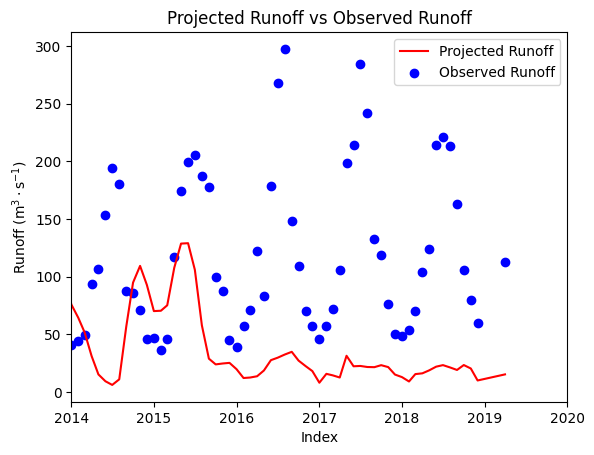

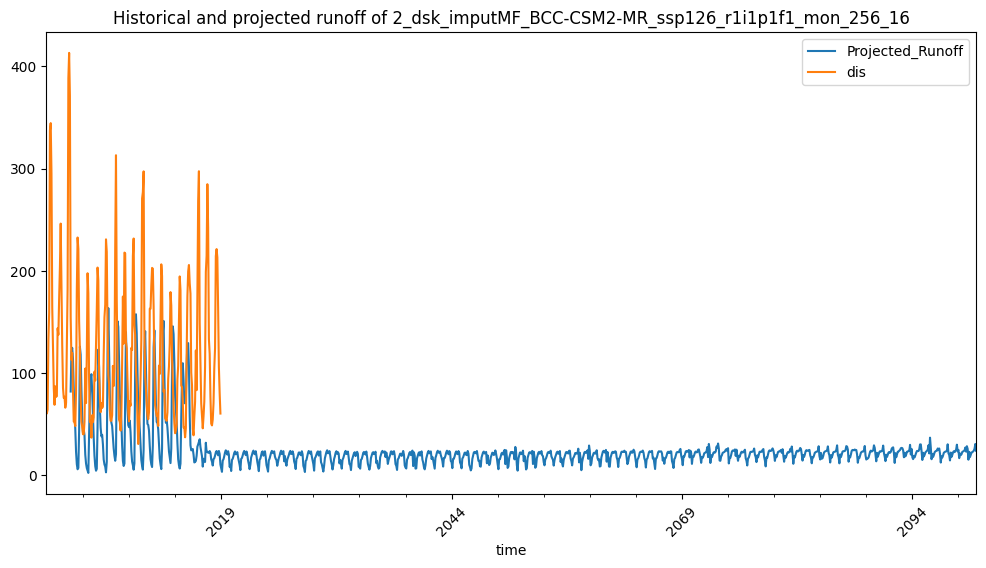

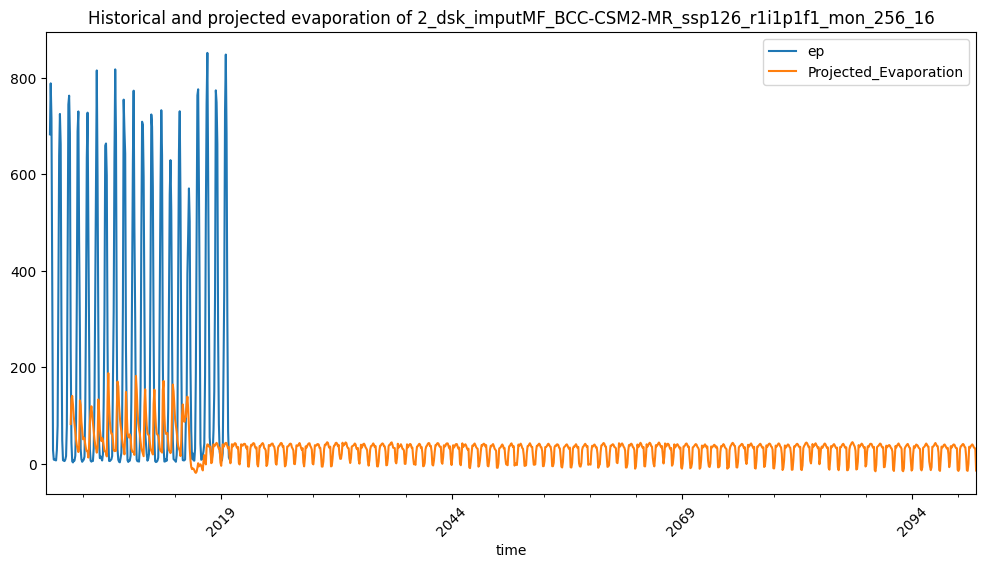

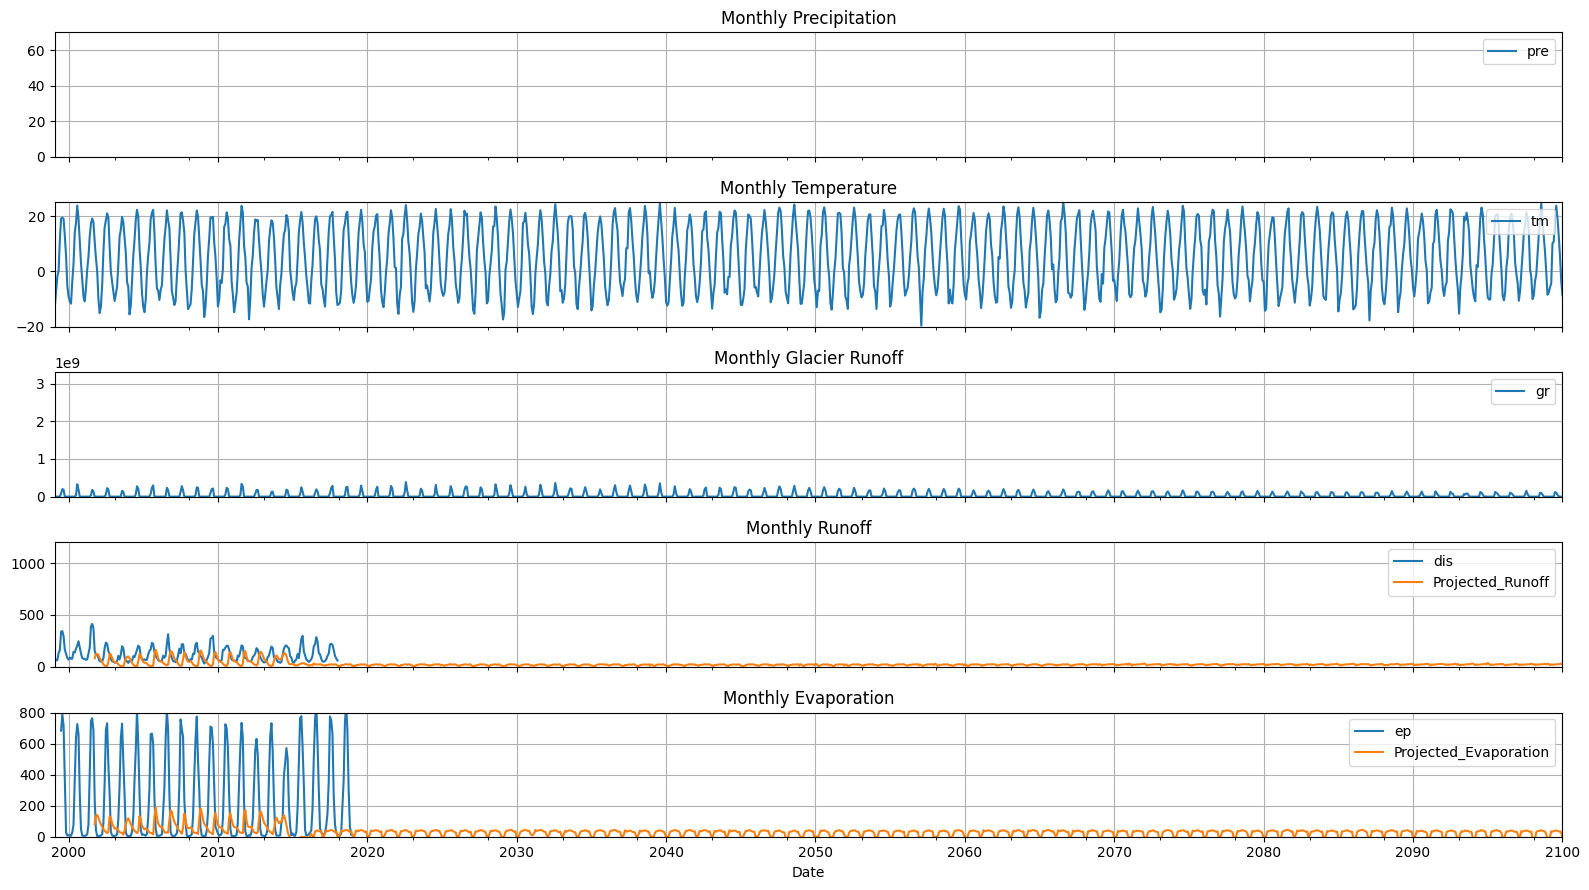

        time           pre        tm            gr          dis           ep  \
0 2000-12-31  1.706089e+23  4.293927  4.674524e+08  1909.748725  2600.657698   
1 2001-12-31  8.857010e+22  4.400203  5.651123e+08  1616.581006  2864.721034   
2 2002-12-31  1.518685e+23  5.136837  3.529667e+08  2163.837634  2987.746315   
3 2003-12-31  1.309780e+23  3.899302  4.708843e+08  1315.763134  2667.715714   
4 2004-12-31  1.532280e+23  4.427310  2.931780e+08  1032.821797  2635.769223   

   Projected_Runoff  Projected_Evaporation  
0               NaN                    NaN  
1               NaN                    NaN  
2        440.076218             479.020760  
3        664.052526             827.275286  
4        478.302317             640.623561  


<Axes: >

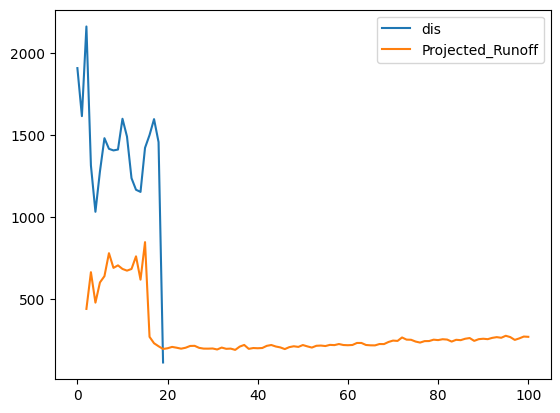

In [84]:
        
        # Convert the 'time' column to datetime format if needed
        df.loc[:,'time'] = pd.to_datetime(df['time'])
        df_full.loc[:,'time'] = pd.to_datetime(df_full['time'])
        # Ensure 'time' is set as the index for both DataFrames if not already
        df.set_index('time', inplace=True)
        df_full.set_index('time', inplace=True)
        historic_pred_df = df_full.dropna(subset='dis')
        historic_pred_df = historic_pred_df.tail(int(valid_rate * len(historic_pred_df)))
        # Define the NSE function
    
        # Calculate NSE for runoff and evaporation
        nse_runoff = nse(historic_pred_df.dis, historic_pred_df.Projected_Runoff)
        nse_evaporation = nse(historic_pred_df.ep, historic_pred_df.Projected_Evaporation)
        print('nse_runoff:',nse_runoff,'nse_ep:',nse_evaporation)
        
        # Plot the line chart for Projected_Runoff
        plt.plot(historic_pred_df.index, historic_pred_df['Projected_Runoff'], label='Projected Runoff', color='red')
        
        # Plot the scatter plot for dis
        plt.scatter(historic_pred_df.index, historic_pred_df['dis'], label='Observed Runoff', color='b')
        
        # Add labels, title, and legend
        plt.xlabel('Index')
        plt.ylabel(r'Runoff ($\mathrm{m^3 \cdot s^{-1}}$)')  # Use LaTeX for units
        plt.title('Projected Runoff vs Observed Runoff')
        plt.xlim(([pd.to_datetime("2014-01"), pd.to_datetime("2020-01-01")]))
        plt.legend()
        
        # Show the plot
        plt.show()
        
        # Plot with a larger figure size
        ax = df_full[[ 'Projected_Runoff','dis']].plot(figsize=(12, 6))
        # Optional: Rotate x-tick labels for better readability
        plt.xticks(rotation=45)
        plt.title(f"Historical and projected runoff of {file_name}")
        # Show the plot
        plt.show()
        # Plot with a larger figure size
        ax = df_full[['ep', 'Projected_Evaporation']].plot(figsize=(12, 6))
        # Optional: Rotate x-tick labels for better readability
        plt.xticks(rotation=45)
        plt.title(f"Historical and projected evaporation of {file_name}")
        # Show the plot
        plt.show()
        import matplotlib.pyplot as plt
        

        
        # Generate a range of ticks every 20 years
        x_ticks = pd.date_range(start=start_date, end=end_date, freq='10Y')
        
        # Set the size of the figure
        fig, axes = plt.subplots(5, 1, figsize=(16, 9), sharex=True,facecolor='w')
        title_list = ['Monthly Precipitation','Monthly Temperature','Monthly Glacier Runoff','Monthly Runoff','Monthly Evaporation']
        
        # Define y-axis limits for each plot
        y_lims = [(0, 70), (-20, 25), (0, 3.3* 1e9), (0, 1200), (0, 800)]
        
        # Loop through the columns and set y-axis limits
        for i, col in enumerate(['pre', 'tm', 'gr', ['dis', 'Projected_Runoff'], ['ep', 'Projected_Evaporation']]):
            df_full[col].plot(ax=axes[i])
            
            # Set y-axis limits
            axes[i].set_ylim(y_lims[i])
            
            # Optional: Add y-axis label, legend, title, grid, etc.
            # axes[i].set_ylabel(col)  # Set y-axis label to the column name
            axes[i].legend(loc='upper right')  # Optional: add legend
            axes[i].set_title(title_list[i])
            
            # Set x-axis limits
            axes[i].set_xlim([start_date, end_date])
            axes[i].set_xticks(x_ticks)
            
            # Set x-axis labels as years (2000, 2020, ..., 2100)
            axes[i].set_xticklabels([str(date.year) for date in x_ticks], rotation=0)
            
            axes[i].grid(True)  # Optional: add grid for clarity
        
        
        
        
        # Set x-axis label for the entire figure
        axes[-1].set_xlabel('Date')  # or adjust label based on your x-axis
        
        # Adjust layout to prevent overlap
        plt.tight_layout()
        plt.savefig(f'{file_name}.svg')
        plt.show()
        
        df_full.to_csv(f"{file_name}_project.csv")
        annual_df = df_full.resample('Y').agg({
            'pre': 'sum',  # If there are any NaNs in the group, the sum will be NaN
            'tm': 'mean',  # The mean will also return NaN if there are NaNs in the group
            'gr': 'sum',   # Same for sum, will return NaN if any NaNs are present
            'dis': 'sum',
            'ep': 'sum',
            'Projected_Runoff': 'sum',
            'Projected_Evaporation': 'sum'
        }, skipna=False)  # Ensures NaNs are preserved in aggregation
        
        # Reset index if needed
        annual_df.reset_index(inplace=True)
        annual_df[['ep', 'dis', 'Projected_Runoff',  'Projected_Evaporation']]=annual_df[['ep', 'dis', 'Projected_Runoff',  'Projected_Evaporation']].replace(0, np.nan,)
        
        # Display the result
        print(annual_df.head())
        
        annual_df[['dis', 'Projected_Runoff']].plot()
        

In [75]:
print(full_predictions)

[[ 81.5948    82.22164 ]
 [120.613174 134.09286 ]
 [124.38541  140.52751 ]
 ...
 [ 25.648283  32.17648 ]
 [ 30.202192  31.46533 ]
 [ 23.574492 -14.259631]]


In [83]:
# Ensure that the DataFrame has the required columns
df_full[['Projected_Runoff', 'Projected_Evaporation']] = np.nan  # Initialize with NaN

# Assign the predictions to the appropriate rows
df_full.iloc[- len(full_predictions) :, df_full.columns.get_loc('Projected_Runoff'):] = full_predictions

# Verify the result
print(df_full.tail())  # Check the last few rows to confirm


            time         tm           pre  dis  ep            gr  \
1207  2100-08-01  19.477888  2.927660e+29  NaN NaN  5.051460e+07   
1208  2100-09-01  13.108997  2.863602e+29  NaN NaN  3.764474e+06   
1209  2100-10-01   5.912106  2.791217e+29  NaN NaN  0.000000e+00   
1210  2100-11-01  -3.263698  2.698928e+29  NaN NaN  0.000000e+00   
1211  2100-12-01  -8.658192  2.644670e+29  NaN NaN  0.000000e+00   

      Projected_Runoff  Projected_Evaporation  
1207         22.843718              37.849224  
1208         23.686445              33.908794  
1209         25.648283              32.176479  
1210         30.202192              31.465330  
1211         23.574492             -14.259631  


In [80]:
full_predictions_df = pd.DataFrame(full_predictions, columns=['Projected_Runoff', 'Projected_Evaporation'])
df_full[['Projected_Runoff', 'Projected_Evaporation']].iloc[-len(full_predictions):] = full_predictions_df


In [81]:
df_full

,time,tm,pre,dis,ep,gr,Projected_Runoff,Projected_Evaporation
0,2000-01-01,-12.723628,4.415131e+21,77.958065,NaN,0.000000e+00,NaN,NaN
1,2000-02-01,-7.082954,6.095188e+21,60.085714,NaN,0.000000e+00,NaN,NaN
2,2000-03-01,-1.889171,2.283079e+22,63.800000,NaN,0.000000e+00,NaN,NaN
3,2000-04-01,0.139775,4.828357e+22,131.486667,NaN,0.000000e+00,NaN,NaN
4,2000-05-01,11.155531,2.565189e+22,158.903226,NaN,-4.191520e-03,NaN,NaN
...,...,...,...,...,...,...,...,...
1207,2100-08-01,19.477888,2.927660e+29,NaN,NaN,5.051460e+07,NaN,NaN
1208,2100-09-01,13.108997,2.863602e+29,NaN,NaN,3.764474e+06,NaN,NaN
1209,2100-10-01,5.912106,2.791217e+29,NaN,NaN,0.000000e+00,NaN,NaN
1210,2100-11-01,-3.263698,2.698928e+29,NaN,NaN,0.000000e+00,NaN,NaN
